# SVM Taxi Demand Prediction — Community Areas

**Full SVM pipeline for predicting Chicago taxi demand per community area, at 4-hour and
1-hour temporal resolution.**

This notebook builds and evaluates SVM regressors that predict taxi demand (trip counts) for
each of Chicago's 77 community areas, using only exogenous features — time of day, weekday,
month, weather, and static spatial context (POI counts). No lagged or autoregressive demand
features are used (course constraint): the task is *"what demand can we expect on a rainy
Sunday from 10–11 am"*, not *"predict hour x+1 from hour x"*.

**Design principles this notebook is built around:**

- **Chronological train/test split** and **`TimeSeriesSplit`** for all cross-validation, since a
  random split on time-series data leaks same-day information between train and test and
  inflates R² (details in the next cell).
- **A complete area × window grid**: every (area, time window) combination is represented, with
  zero-filled counts for windows without trips, so the model both trains on and is evaluated
  against genuine "zero demand" windows.
- **A non-trivial profile baseline** (the train-set mean demand per area × hour × weekday) that
  every model must beat, plus a **skill score** relative to this baseline — the headline metric
  throughout, since raw R²/MAE aren't comparable across areas of wildly different demand scale
  (see section 14).
- **A kernel ladder**: starting from no kernel (LinearSVR), through linear/poly/RBF/sigmoid SVR,
  before tuning the best-performing kernel (RBF) via GridSearch.

**Notebook structure:**

1. Load and clean the combined 2024–2026 taxi + weather data.
2. Build the complete area × window demand panel with time and weather features.
3. Select which of the 77 areas have enough demand signal for their own model (median-demand
   threshold); pool the rest onto the profile baseline.
4. Define the shared feature set and evaluation helpers (metrics, skill score, back-transform).
5. Compute the profile baseline every model is measured against.
6. Fit a single global LinearSVR across all areas (the assignment's starting point) to show why
   per-area models are needed.
7. Per-area models: compare SVR kernels on one representative area, then fit LinearSVR and
   default-RBF SVR for every included area.
8. Tune the RBF SVR per area with `GridSearchCV` + `TimeSeriesSplit`.
9. Rolling-origin backtest of the tuned model across all five test months.
10. Repeat the per-area modelling at 1-hour resolution.
11. Report profile-baseline performance for the areas excluded from per-area modelling.
12. Compare all models and resolutions side by side.
13. Discuss shortfalls and improvement levers.
14. Interpret what the results say about whether the SVR actually beats the weekly pattern.

**Scope:** spatial unit = Chicago's 77 community areas; models = SVM only. Census-tract
resolution and neural networks are handled separately.


## Validation Strategy

The prediction target is a **time series per area**, so the validation split must respect time:

- **Chronological holdout**: train on 2024-01-01 … 2025-12-31 (two full years), test on
  2026-01-01 … 2026-05-31 (the five most recent complete months). This mimics deployment:
  the model is fitted on the past and asked about the future. A random split would place
  windows from the *same day* (nearly identical weather, same weekday and season) in both
  train and test — even without lagged features this leaks information and inflates R².
- **Two full years of training data** mean every calendar month is observed twice: the model
  can separate the seasonal pattern from one-off events of a single year, and the cyclic month
  features never have to extrapolate to unseen values in the test period.
- **`TimeSeriesSplit` (3 folds) inside GridSearch**: each CV fold trains on an initial segment and
  validates on the segment that follows it, so hyperparameters are also selected without look-ahead.
- **Rolling-origin backtest** (section 9): in addition to the single holdout, the model is
  evaluated the way it would be operated in practice — retrain on everything before month *m*,
  predict month *m*, slide forward through all five test months. This shows whether the error
  is stable over time or driven by one unusual month.
- **Data currency**: the Chicago portal reports trips with a lag of several weeks; June 2026 was
  still nearly empty at download time (2026-07) and is excluded. Year-over-year demand drift
  (fleet size, pricing) is deliberately part of the test error — a deployed model faces it too.


In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import contextily as ctx

from sklearn.svm import SVR, LinearSVR
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import ConvergenceWarning

# LinearSVR (liblinear) at high C values doesn't reach its optimum within max_iter on this
# data -- the fits are still valid (just not at the exact optimum), and liblinear's tolerance
# is effectively unreachable for these C/data combinations, so raising max_iter further would
# not remove the warning either. Silenced rather than chasing an unreachable tolerance across
# ~1,000 grid-search fits.
warnings.filterwarnings("ignore", category=ConvergenceWarning)

TAXI_DATA_PATH       = "../data/chicago_taxi_2024_2026_clean.parquet"
WEATHER_DATA_PATH    = "../data/chicago_weather_2024_2026_hourly.csv"
POI_DATA_PATH        = "../data/poi_chicago.geojson"
COMMUNITY_AREAS_PATH = "../data/community_areas_chicago.geojson"

# Data range covered by the cleaned parquet (June 2026+ excluded: portal reporting lag)
DATA_START    = pd.Timestamp("2024-01-01")
DATA_END_EXCL = pd.Timestamp("2026-06-01")

# Chronological split: train 2024-2025 (two full years), test Jan-May 2026
TRAIN_END = pd.Timestamp("2026-01-01")

# Temporal resolutions analysed in this notebook
RESOLUTIONS = ["4h", "1h"]
WINDOW_HOURS = {"4h": 4, "1h": 1}

# Minimum median demand (trips per window) for an area to get its own SVR model. Both
# values are derived from the same "enough signal" cutoff of ~2.5 trips/hour median demand
# (4h: 10 trips/window == 2.5/hour) rather than picked independently per resolution. The 1h
# threshold rounds this UP to 3, not down to 2: at 1h a per-area model has ~4x less signal
# per window than at 4h, so it is more important to err toward excluding a marginal area
# than to include one with insufficient data. A sensitivity check in section 3 confirms the
# included/excluded split is not sensitive to the exact cutoff.
DEMAND_THRESHOLDS = {"4h": 10, "1h": 3}

WEATHER_COLS = ["temperature_2m", "precipitation", "snowfall", "wind_speed_10m", "cloud_cover"]

# Representative area used for the feature correlation check (section 4.1) and the kernel
# comparison (section 7.1) -- CA 8 (Near North Side) is the highest-volume included area.
KERNEL_AREA = 8


## 1. Data Loading

The cleaned parquet covers **2024-01-01 … 2026-05-31** (June 2026+ excluded — portal reporting
lag, see `00_data_loading`) and contains **all** trips (also those without geo information) plus
the `pickup_flag` / `dropoff_flag` columns. For demand prediction only the **pickup** location
matters — a trip generates demand where it starts. We therefore keep every trip with a pickup
community area, regardless of whether the dropoff is known (~98 % of trips).

`weather_code` (non-ordinal WMO codes), `weather_description` (text) and `apparent_temperature`
(r > 0.95 with `temperature_2m`) are dropped from the weather data.


In [2]:
# Only the two columns needed for demand aggregation are loaded (fast + memory-friendly)
taxi = pd.read_parquet(TAXI_DATA_PATH, columns=["trip_start_timestamp", "pickup_community_area"])
n_raw = len(taxi)

# Constraint: pickup location must be known; dropoff is irrelevant for demand
taxi = taxi[taxi["pickup_community_area"].notna()].copy()
taxi["pickup_community_area"] = taxi["pickup_community_area"].astype(int)

print(f"Trips total:              {n_raw:,}")
print(f"Trips with pickup CA:     {len(taxi):,} ({len(taxi)/n_raw*100:.1f}%)")
print(f"Distinct community areas: {taxi['pickup_community_area'].nunique()}")
print(f"Time range:               {taxi['trip_start_timestamp'].min()} - {taxi['trip_start_timestamp'].max()}")
print("\nTrips per year:")
print(taxi["trip_start_timestamp"].dt.year.value_counts().sort_index().to_string())

weather = pd.read_csv(WEATHER_DATA_PATH)
weather["datetime"] = pd.to_datetime(weather["datetime"])
weather = weather[["datetime"] + WEATHER_COLS]
print(f"\nWeather rows: {len(weather):,} (hourly, {weather['datetime'].min()} - {weather['datetime'].max()})")


Trips total:              14,465,650
Trips with pickup CA:     14,201,846 (98.2%)
Distinct community areas: 77
Time range:               2024-01-01 00:00:00 - 2026-05-31 23:45:00

Trips per year:
trip_start_timestamp
2024    5603016
2025    6094495
2026    2504335

Weather rows: 21,168 (hourly, 2024-01-01 00:00:00 - 2026-05-31 23:00:00)


## 2. Building the Demand Panel — Complete Area × Window Grid

`groupby(area, window).size()` only produces rows for windows in which **at least one trip
occurred**. Leaving missing windows out of the panel would have two consequences:

1. The model would never see "zero demand" during training, so it could not learn that e.g.
   Montclare at 4 am has no demand — it would systematically over-predict quiet windows.
2. Evaluation would silently skip exactly those windows, making the reported errors too
   optimistic — especially at 1-hour resolution, where many overnight windows are genuinely
   empty.

To avoid this, we reindex onto the **complete grid of 77 areas × all windows in the data
range** and fill missing windows with `count = 0`. Weather is aggregated to the window size
*independently* of the taxi data, so zero-demand windows also get weather features.

Time features: cyclic encodings (sin/cos) for hour, weekday and month, plus weekend and
US-federal-holiday flags. The raw `hour` / `day_of_week` columns are kept for the profile
baseline but are **not** model features.


In [3]:
US_HOLIDAYS = pd.to_datetime([
    # 2024
    "2024-01-01", "2024-01-15", "2024-02-19", "2024-05-27",
    "2024-06-19", "2024-07-04", "2024-09-02", "2024-10-14",
    "2024-11-11", "2024-11-28", "2024-12-25",
    # 2025
    "2025-01-01", "2025-01-20", "2025-02-17", "2025-05-26",
    "2025-06-19", "2025-07-04", "2025-09-01", "2025-10-13",
    "2025-11-11", "2025-11-27", "2025-12-25",
    # 2026 (data ends 2026-05-31)
    "2026-01-01", "2026-01-19", "2026-02-16", "2026-05-25",
])

ALL_AREAS = np.arange(1, 78)  # official community areas 1..77


def build_panel(freq):
    """Complete (area x window) demand panel with weather and time features."""
    # Trip counts per (area, window)
    window = taxi["trip_start_timestamp"].dt.floor(freq).rename("timestamp")
    counts = (
        taxi.groupby(["pickup_community_area", window])
        .size()
        .rename("count")
    )

    # Complete grid: every area x every window of the data range, missing windows = 0 trips
    all_windows = pd.date_range(DATA_START, DATA_END_EXCL, freq=freq, inclusive="left")
    grid = pd.MultiIndex.from_product(
        [ALL_AREAS, all_windows], names=["community_area", "timestamp"]
    )
    panel = counts.reindex(grid, fill_value=0).reset_index()

    # Weather aggregated to the window size, joined independently of taxi coverage
    w = weather.copy()
    w["timestamp"] = w["datetime"].dt.floor(freq)
    w_agg = w.groupby("timestamp")[WEATHER_COLS].mean().reset_index()
    panel = panel.merge(w_agg, on="timestamp", how="left")

    # Time features
    panel["hour"]        = panel["timestamp"].dt.hour
    panel["day_of_week"] = panel["timestamp"].dt.dayofweek
    month                = panel["timestamp"].dt.month

    panel["hour_sin"]        = np.sin(2 * np.pi * panel["hour"] / 24)
    panel["hour_cos"]        = np.cos(2 * np.pi * panel["hour"] / 24)
    panel["day_of_week_sin"] = np.sin(2 * np.pi * panel["day_of_week"] / 7)
    panel["day_of_week_cos"] = np.cos(2 * np.pi * panel["day_of_week"] / 7)
    panel["month_sin"]       = np.sin(2 * np.pi * month / 12)
    panel["month_cos"]       = np.cos(2 * np.pi * month / 12)
    panel["is_weekend"]      = (panel["day_of_week"] >= 5).astype(int)
    panel["is_holiday"]      = panel["timestamp"].dt.date.isin(US_HOLIDAYS.date).astype(int)

    return panel.sort_values(["community_area", "timestamp"]).reset_index(drop=True)


panels = {freq: build_panel(freq) for freq in RESOLUTIONS}

for freq, panel in panels.items():
    zero_share = (panel["count"] == 0).mean() * 100
    print(f"{freq}: {len(panel):,} rows "
          f"({panel['community_area'].nunique()} areas x {panel['timestamp'].nunique():,} windows), "
          f"zero-demand windows: {zero_share:.1f}%")


4h: 407,484 rows (77 areas x 5,292 windows), zero-demand windows: 18.9%
1h: 1,629,936 rows (77 areas x 21,168 windows), zero-demand windows: 43.7%


## 3. Demand Heterogeneity & Area Selection

Demand differs by orders of magnitude between areas (CA 8 Near North Side vs. CA 18
Montclare). A per-area model is only meaningful where there is enough demand signal; below the
threshold the target has so little variance that no regression model can beat the mean (R²
turns negative although the absolute error is < 1 trip).

Note that with the zero-filled grid (section 2) the medians are lower than a naive count over
non-empty windows only would suggest, so the thresholds below are checked directly against the
bar charts rather than assumed from raw demand figures. The 4h and 1h thresholds are derived
from the same per-hour demand-rate cutoff rather than chosen independently (see the code
comment), and a brief sensitivity check below confirms the included/excluded split is not
sensitive to the exact cutoff value.


In [4]:
def area_demand_stats(panel):
    return (
        panel.groupby("community_area")["count"]
        .agg(median="median", mean="mean", max="max", std="std")
        .round(2)
        .reset_index()
    )


area_stats = {freq: area_demand_stats(panels[freq]) for freq in RESOLUTIONS}
included_areas = {}
excluded_areas = {}

for freq in RESOLUTIONS:
    thr = DEMAND_THRESHOLDS[freq]
    stats = area_stats[freq]
    included_areas[freq] = sorted(stats.loc[stats["median"] >= thr, "community_area"].tolist())
    excluded_areas[freq] = sorted(stats.loc[stats["median"] < thr, "community_area"].tolist())
    print(f"{freq}: threshold = median >= {thr} trips/window -> "
          f"{len(included_areas[freq])} areas included, {len(excluded_areas[freq])} excluded")
    print(f"     included: {included_areas[freq]}\n")


4h: threshold = median >= 10 trips/window -> 20 areas included, 57 excluded
     included: [1, 2, 3, 6, 7, 8, 22, 24, 28, 32, 33, 35, 38, 41, 43, 44, 56, 69, 76, 77]

1h: threshold = median >= 3 trips/window -> 18 areas included, 59 excluded
     included: [1, 2, 3, 6, 7, 8, 24, 28, 32, 33, 35, 38, 41, 43, 44, 56, 76, 77]



In [ ]:
# Sensitivity check: does the exact threshold value matter? Compare the chosen cutoff against
# neighbouring values (+/-20%) and show how many areas would flip in or out of the included set.
SENSITIVITY_THRESHOLDS = {"4h": [8, 10, 12], "1h": [2, 3, 4]}

for freq in RESOLUTIONS:
    stats = area_stats[freq]
    chosen = set(included_areas[freq])
    print(f"{freq}: chosen threshold = {DEMAND_THRESHOLDS[freq]} -> {len(chosen)} areas included")
    for thr in SENSITIVITY_THRESHOLDS[freq]:
        if thr == DEMAND_THRESHOLDS[freq]:
            continue
        alt = set(stats.loc[stats["median"] >= thr, "community_area"].tolist())
        diff = sorted(alt.symmetric_difference(chosen))
        print(f"  threshold={thr}: {len(alt)} areas included -- {len(diff)} area(s) differ from "
              f"the chosen cutoff: {diff}")
    print()


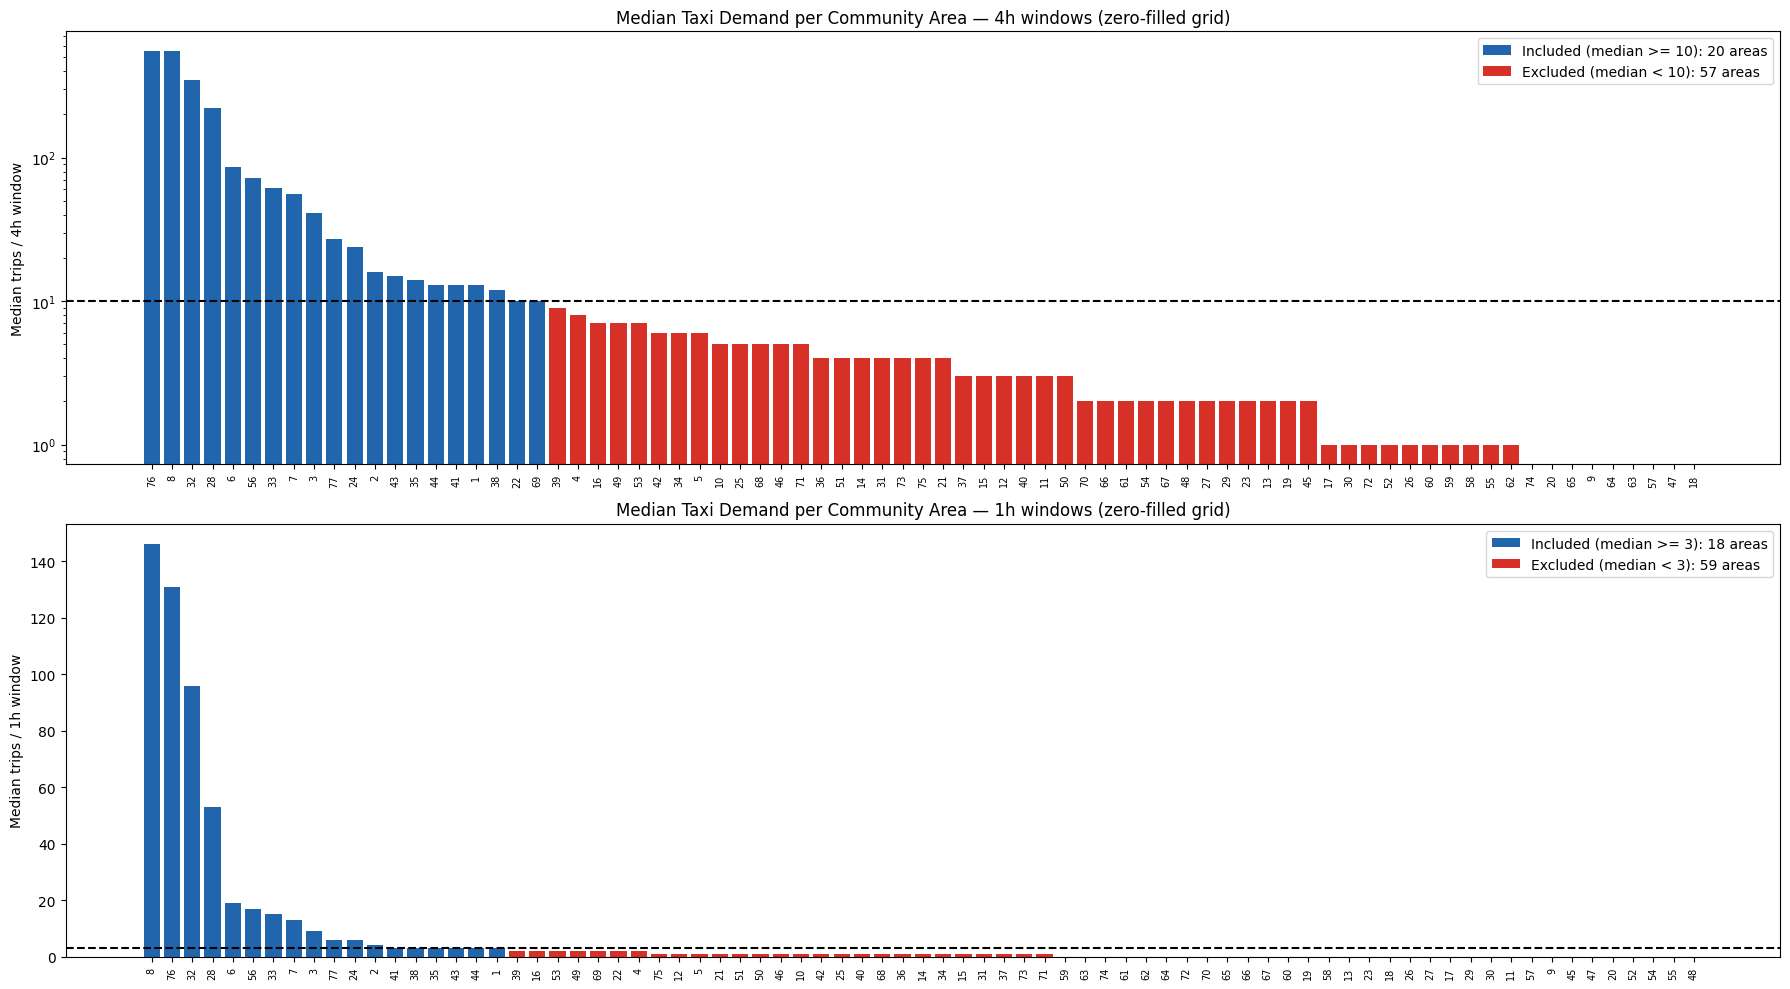

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

for ax, freq in zip(axes, RESOLUTIONS):
    thr = DEMAND_THRESHOLDS[freq]
    sorted_stats = area_stats[freq].sort_values("median", ascending=False)
    colors = ["#2166ac" if m >= thr else "#d73027" for m in sorted_stats["median"]]

    ax.bar(range(len(sorted_stats)), sorted_stats["median"], color=colors, width=0.8)
    ax.axhline(y=thr, color="black", linestyle="--", linewidth=1.5)
    ax.set_xticks(range(len(sorted_stats)))
    ax.set_xticklabels(sorted_stats["community_area"].astype(str), rotation=90, fontsize=7)
    ax.set_ylabel(f"Median trips / {freq} window")
    ax.set_title(f"Median Taxi Demand per Community Area — {freq} windows (zero-filled grid)")
    ax.legend(handles=[
        Patch(facecolor="#2166ac", label=f"Included (median >= {thr}): {len(included_areas[freq])} areas"),
        Patch(facecolor="#d73027", label=f"Excluded (median < {thr}): {len(excluded_areas[freq])} areas"),
    ])

axes[0].set_yscale("log")   # 4h medians span 3 orders of magnitude
plt.tight_layout()
plt.show()


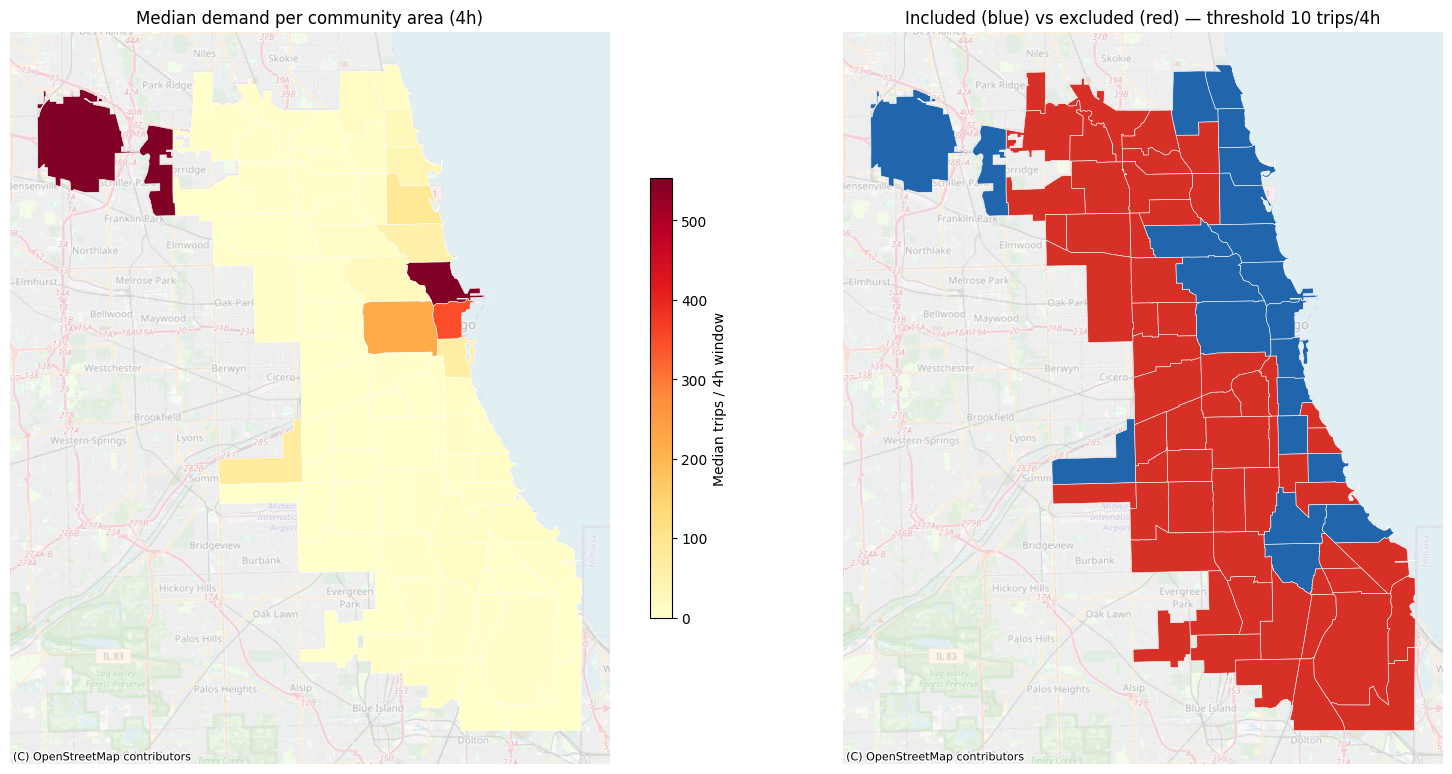

In [6]:
community_areas_gdf = gpd.read_file(COMMUNITY_AREAS_PATH)
community_areas_gdf["area_numbe"] = community_areas_gdf["area_numbe"].astype(int)

gdf = community_areas_gdf.merge(
    area_stats["4h"], left_on="area_numbe", right_on="community_area", how="left"
).to_crs(epsg=3857)
gdf["included"] = gdf["community_area"].isin(included_areas["4h"])

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

gdf.plot(ax=axes[0], column="median", cmap="YlOrRd", legend=True,
         legend_kwds={"label": "Median trips / 4h window", "shrink": 0.6},
         edgecolor="white", linewidth=0.4)
ctx.add_basemap(axes[0], crs=gdf.crs, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.35)
axes[0].set_title("Median demand per community area (4h)")
axes[0].axis("off")

gdf.plot(ax=axes[1], color=gdf["included"].map({True: "#2166ac", False: "#d73027"}),
         edgecolor="white", linewidth=0.4)
ctx.add_basemap(axes[1], crs=gdf.crs, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.35)
axes[1].set_title(f"Included (blue) vs excluded (red) — threshold {DEMAND_THRESHOLDS['4h']} trips/4h")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## 4. Feature Set & Shared Helpers

13 exogenous features, identical for every model (no lagged demand — course constraint):

| Group | Features |
|---|---|
| Time (cyclic) | `hour_sin/cos`, `day_of_week_sin/cos`, `month_sin/cos` |
| Weather | `temperature_2m`, `precipitation`, `snowfall`, `wind_speed_10m`, `cloud_cover` |
| Binary flags | `is_weekend`, `is_holiday` |

The target is `log1p(count)` (heavy right tail, `log1p(0) = 0` handles the zero-filled windows),
back-transformed with `expm1` and **clipped at 0** before computing metrics — all reported
metrics are in original trips-per-window scale.

POI counts per area (static, from OSM) are used **only in the global model** (section 5): within
a single area they are constant, so per-area models cannot use them.


In [7]:
FEATURE_COLS = [
    "temperature_2m", "precipitation", "snowfall", "wind_speed_10m", "cloud_cover",
    "hour_sin", "hour_cos", "day_of_week_sin", "day_of_week_cos",
    "month_sin", "month_cos", "is_weekend", "is_holiday",
]

# expm1(709) is already ~1.8e308 (float64 max); a few kernels (esp. sigmoid, which is not
# a true Mercer kernel) can extrapolate to log-scale predictions in the thousands on test
# data, which would overflow expm1 to inf and crash downstream metrics. Clipping the
# log-scale prediction first keeps such a blown-up model in the comparison (with a
# terrible but finite score) instead of crashing the cell.
LOG_PRED_CAP = 20  # expm1(20) ~ 4.85e8 trips/window -- far above any real demand, just an overflow guard


def chrono_split(df):
    """Chronological train/test split at TRAIN_END (rows must contain 'timestamp')."""
    return df[df["timestamp"] < TRAIN_END], df[df["timestamp"] >= TRAIN_END]


def metrics(y_true, y_pred):
    return {
        "r2":   round(r2_score(y_true, y_pred), 4),
        "mae":  round(mean_absolute_error(y_true, y_pred), 2),
        "rmse": round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 2),
    }


def predict_counts(model, X):
    """Back-transform log-scale predictions to counts, clipped at 0."""
    y_log = np.clip(model.predict(X), -LOG_PRED_CAP, LOG_PRED_CAP)
    return np.clip(np.expm1(y_log), 0, None)


def train_per_area(panel, areas, make_model, feature_cols=FEATURE_COLS, verbose=False):
    """Fit one model per area (chronological split); returns results df, models, pooled preds."""
    results, models = [], {}
    pooled = {"y_true": [], "y_pred": [], "area": []}

    for area in areas:
        df_area = panel[panel["community_area"] == area]
        train, test = chrono_split(df_area)

        model = make_model()
        model.fit(train[feature_cols], np.log1p(train["count"]))

        y_true = test["count"].to_numpy(dtype=float)
        y_pred = predict_counts(model, test[feature_cols])

        results.append({
            "community_area": int(area),
            "median_demand":  float(df_area["count"].median()),
            "n_train": len(train), "n_test": len(test),
            **metrics(y_true, y_pred),
        })
        models[int(area)] = model
        pooled["y_true"].extend(y_true)
        pooled["y_pred"].extend(y_pred)
        pooled["area"].extend([int(area)] * len(y_true))
        if verbose:
            print(f"  CA {area:2d} done ({len(train)} train rows)")

    return pd.DataFrame(results), models, pooled


def pooled_metrics(pooled):
    return metrics(np.asarray(pooled["y_true"]), np.asarray(pooled["y_pred"]))


def skill_vs_baseline(results_df, freq):
    """Per-area skill score: 1 - MAE_model / MAE_baseline.

    Unlike R2 or raw MAE, this is comparable *across* areas regardless of demand scale: a
    skill of 0.3 means "30% lower absolute error than the naive weekly profile" whether the
    area does 10 or 1,600 trips/window. MAE (not RMSE) is used deliberately -- the baseline
    predicts the training-set mean per (hour, weekday), which is already the RMSE-optimal
    predictor for that grouping, so an RMSE-based skill would be structurally biased toward
    the baseline. MAE carries no such built-in advantage and is also less sensitive to the
    rare huge-demand spikes (events, holidays) that would otherwise dominate a squared-error
    ratio computed over a few hundred test windows per area.
    """
    base = baseline_results[freq][["community_area", "mae"]].rename(columns={"mae": "mae_base"})
    merged = results_df.merge(base, on="community_area")
    return (1 - merged["mae"] / merged["mae_base"]).rename("skill")


def weighted_skill_vs_baseline(results_df, freq):
    """Demand-weighted mean skill: each area's skill is weighted by its own median demand,
    so high-volume areas -- where the fleet is actually deployed -- drive the number. This is
    the headline metric: the business case is that the taxi fleet is allocated mostly to
    high-demand areas, so those areas matter most for evaluating the model. The unweighted
    median (every area counted equally, "how does a typical area do") is kept alongside as a
    secondary, spatial-coverage view -- they answer different questions, not the same one
    twice.
    """
    skill = skill_vs_baseline(results_df, freq)
    weights = results_df["median_demand"].to_numpy()
    return float(np.average(skill.to_numpy(), weights=weights))


def print_results(label, results_df, pooled, freq):
    """Headline number is the demand-weighted mean skill vs. the profile baseline (see
    weighted_skill_vs_baseline) -- high-volume areas, where the fleet is actually deployed,
    drive this number. The unweighted median skill (every area counted equally) is kept as a
    secondary spatial-coverage view. Pooled metrics and R2/MAE are supporting detail.
    """
    skill = skill_vs_baseline(results_df, freq)
    w_skill = weighted_skill_vs_baseline(results_df, freq)
    pm = pooled_metrics(pooled)
    print(f"{label}")
    print(f"  Skill vs. baseline -- demand-weighted (headline): {w_skill:+.3f}")
    print(f"  Skill vs. baseline -- unweighted median across {len(skill)} areas: {skill.median():+.3f}  "
          f"(areas with negative skill: {(skill < 0).sum()})")
    print(f"  Per area (detail): median R2={results_df['r2'].median():.3f}  median MAE={results_df['mae'].median():.2f}")
    print(f"  Pooled   (detail): R2={pm['r2']:.3f}  MAE={pm['mae']:.2f}  RMSE={pm['rmse']:.2f}  "
          f"(trips/window, dominated by high-volume areas)")


### 4.1 Feature Correlation Check

Before fitting any model: are the 13 input features providing independent information, and
which of them actually track demand? The heatmap below shows pairwise Pearson correlations
among the features (computed once per unique timestamp -- weather and time features are
identical across all 77 areas, so duplicating them per area would not change the correlations,
only the row count) plus each feature's correlation with `log1p(count)` for CA 8, the
representative area used throughout sections 7-8.


In [ ]:
corr_df = (
    panels["4h"].drop_duplicates(subset="timestamp").set_index("timestamp")[FEATURE_COLS].copy()
)
corr_df["log1p(count), CA 8"] = np.log1p(
    panels["4h"].loc[panels["4h"]["community_area"] == KERNEL_AREA].set_index("timestamp")["count"]
)
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(11, 10))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
labels = corr_matrix.columns
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        r = corr_matrix.iloc[i, j]
        ax.text(j, i, f"{r:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(r) > 0.6 else "black")
plt.colorbar(im, ax=ax, shrink=0.8, label="Pearson correlation")
ax.set_title("Feature correlation matrix (+ log1p(count), CA 8, for target reference)")
plt.tight_layout()
plt.show()

print("Correlation with target (log1p(count), CA 8), sorted by |r|:")
print(corr_matrix["log1p(count), CA 8"].drop("log1p(count), CA 8")
      .sort_values(key=abs, ascending=False).round(3).to_string())

print("\nFeature pairs with |r| > 0.5 (excluding the target):")
feat_corr = corr_matrix.loc[FEATURE_COLS, FEATURE_COLS]
for i, a in enumerate(FEATURE_COLS):
    for b in FEATURE_COLS[i + 1:]:
        r = feat_corr.loc[a, b]
        if abs(r) > 0.5:
            print(f"  {a} vs {b}: r={r:.3f}")


**What this shows:**

- **`hour_cos` dominates** (r = -0.82 with CA 8's log-demand) -- time of day is overwhelmingly
  the strongest single driver, which lines up with the section 14 finding that the profile
  baseline (built on exact hour x weekday combinations) is hard to beat: most of the demand
  signal already lives in a single, easily-learned time-of-day feature. But a single cosine has
  exactly one peak and one trough per day -- it cannot represent a genuinely bimodal pattern
  (separate morning and evening rush peaks), no matter how high its raw correlation is. This is
  concrete evidence for the section 14 hypothesis: adding a **second harmonic**
  (`sin(4*pi*hour/24)`, `cos(4*pi*hour/24)`) would let the model represent two peaks instead of
  one, without adding any lagged-demand information.
- **Weather barely correlates with demand at all**: `precipitation`, `snowfall`,
  `wind_speed_10m` and `cloud_cover` all sit at |r| < 0.04. `temperature_2m` is the strongest
  weather feature at r = 0.21, still weak. This is *linear* correlation only -- an RBF kernel
  can still exploit non-linear or threshold effects (e.g. "only heavy rain matters") that
  Pearson's r would miss -- but it's consistent with section 14's finding that weather isn't
  where the model's shortfall against the baseline comes from.
- **Two feature pairs are moderately redundant, both for structural reasons rather than data
  quirks:**
  - `temperature_2m` vs. `month_cos`: r = -0.68 -- cold months and low temperatures move
    together, so these two features partly encode the same seasonal signal.
  - `day_of_week_sin` vs. `is_weekend`: r = -0.79 -- `is_weekend` is literally derived from
    day-of-week, so the overlap is expected. `is_weekend` is still worth keeping: it gives the
    model an explicit sharp Friday-to-Saturday step that a smooth sinusoid can't represent on
    its own -- the same single-harmonic limitation as `hour_cos` above, just for the week
    instead of the day.
- **Everything else is close to independent** (most off-diagonal values are under 0.2), so
  outside these two expected pairs there is little redundancy to clean up.


## 5. Profile Baseline — the Bar Every Model Must Clear

Before any SVM: how far do you get with **no machine learning at all**? The profile baseline
predicts, for each test window, the *training-set mean demand of that area for that
time-of-day × weekday combination* (fallback: area mean for unseen combinations).

This is the correct reference point for this task, because most of taxi demand is a repeating
weekly pattern. An SVR is only worth its complexity if it beats this baseline — e.g. by
exploiting weather, holidays, and seasonal drift. The **skill score** used later is
`1 − MAE_model / MAE_baseline` (> 0 means better than the baseline).


In [8]:
def profile_baseline(panel, areas):
    """Train-mean per (area, hour, day_of_week) profile; returns results df + pooled preds."""
    results = []
    pooled = {"y_true": [], "y_pred": [], "area": []}

    for area in areas:
        df_area = panel[panel["community_area"] == area]
        train, test = chrono_split(df_area)

        profile = train.groupby(["hour", "day_of_week"])["count"].mean()
        fallback = train["count"].mean()
        keys = pd.MultiIndex.from_arrays([test["hour"], test["day_of_week"]])
        y_pred = profile.reindex(keys).fillna(fallback).to_numpy()
        y_true = test["count"].to_numpy(dtype=float)

        results.append({
            "community_area": int(area),
            "median_demand":  float(df_area["count"].median()),
            **metrics(y_true, y_pred),
        })
        pooled["y_true"].extend(y_true)
        pooled["y_pred"].extend(y_pred)
        pooled["area"].extend([int(area)] * len(y_true))

    return pd.DataFrame(results), pooled


baseline_results, baseline_pooled = {}, {}
for freq in RESOLUTIONS:
    baseline_results[freq], baseline_pooled[freq] = profile_baseline(panels[freq], ALL_AREAS)
    pm = pooled_metrics(baseline_pooled[freq])
    print(f"Profile baseline — {freq} windows, all 77 areas")
    print(f"  Median R2={baseline_results[freq]['r2'].median():.3f}  "
          f"Median MAE={baseline_results[freq]['mae'].median():.2f}  "
          f"Pooled R2={pm['r2']:.3f}  Pooled MAE={pm['mae']:.2f}")
    print()


Profile baseline — 4h windows, all 77 areas
  Median R2=0.304  Median MAE=1.99  Pooled R2=0.933  Pooled MAE=9.52

Profile baseline — 1h windows, all 77 areas
  Median R2=0.138  Median MAE=0.79  Pooled R2=0.919  Pooled MAE=2.85



## 6. Global Model Without a Kernel (LinearSVR) — the Assignment's Starting Point

*"Simply start without a kernel."* — one linear SVR across **all 77 areas** at 4-hour resolution.
Two variants of increasing complexity:

- **Variant A — exogenous only:** time + weather + static POI counts per area. The POI features
  are the only thing telling the model *where* it is. This variant would generalise to unseen
  areas.
- **Variant B — + area fixed effects:** one-hot encoding of the community area, so the model
  learns one intercept per area. (POI features are then dropped — they are collinear with the
  dummies.)

Expect the pooled R² to look impressive because the model separates high- from low-demand
areas, while the per-area breakdown reveals that sparse areas are predicted poorly — the
pooled loss is dominated by the highest-volume areas (CA 8 / 32 / 76). This motivates the
per-area models in section 7.


In [9]:
# Static POI features per community area (OSM via Overpass)
gdf_poi = gpd.read_file(POI_DATA_PATH)
ca_gdf = gpd.read_file(COMMUNITY_AREAS_PATH)
gdf_poi = gdf_poi.to_crs(ca_gdf.crs)

poi_categories = ["amenity", "public_transport", "railway", "tourism", "office",
                  "aeroway", "shop", "leisure", "healthcare"]

poi_joined = gpd.sjoin(
    gdf_poi[poi_categories + ["geometry"]],
    ca_gdf[["area_numbe", "geometry"]],
    how="left", predicate="within",
)

poi_features = pd.DataFrame({
    f"poi_{col}": poi_joined[poi_joined[col].notna()].groupby("area_numbe").size()
    for col in poi_categories
})
poi_features.index = poi_features.index.astype(int)
poi_features = poi_features.reindex(ALL_AREAS).fillna(0).astype(int)
poi_features = poi_features.rename_axis("community_area").reset_index()
POI_COLS = [c for c in poi_features.columns if c != "community_area"]

print(f"POI features for {len(poi_features)} areas: {POI_COLS}")


POI features for 77 areas: ['poi_amenity', 'poi_public_transport', 'poi_railway', 'poi_tourism', 'poi_office', 'poi_aeroway', 'poi_shop', 'poi_leisure', 'poi_healthcare']


In [10]:
df_global = panels["4h"].merge(poi_features, on="community_area", how="left")
dummies = pd.get_dummies(df_global["community_area"], prefix="area", drop_first=True).astype(float)
DUMMY_COLS = list(dummies.columns)
df_global = pd.concat([df_global, dummies], axis=1)

train_g, test_g = chrono_split(df_global)


def fit_global(feature_cols, label):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm",    LinearSVR(C=1.0, epsilon=0.1, max_iter=20000, random_state=42)),
    ])
    t0 = time.time()
    model.fit(train_g[feature_cols], np.log1p(train_g["count"]))

    y_true = test_g["count"].to_numpy(dtype=float)
    y_pred = predict_counts(model, test_g[feature_cols])
    pm = metrics(y_true, y_pred)

    per_area = (
        pd.DataFrame({"area": test_g["community_area"].to_numpy(), "y": y_true, "yhat": y_pred})
        .groupby("area")
        .apply(lambda g: r2_score(g["y"], g["yhat"]))
        .rename("r2")
    )
    print(f"{label}  ({time.time()-t0:.0f}s)")
    print(f"  Pooled:   R2={pm['r2']:.3f}  MAE={pm['mae']:.2f}  RMSE={pm['rmse']:.2f}")
    print(f"  Per area: median R2={per_area.median():.3f}  |  areas with R2 < 0: {(per_area < 0).sum()} of 77\n")
    return model, per_area


global_a_model, global_a_r2 = fit_global(FEATURE_COLS + POI_COLS,  "Global LinearSVR A — time + weather + POI")
global_b_model, global_b_r2 = fit_global(FEATURE_COLS + DUMMY_COLS, "Global LinearSVR B — time + weather + area fixed effects")


Global LinearSVR A — time + weather + POI  (185s)
  Pooled:   R2=0.657  MAE=19.61  RMSE=84.16
  Per area: median R2=0.005  |  areas with R2 < 0: 38 of 77

Global LinearSVR B — time + weather + area fixed effects  (938s)
  Pooled:   R2=0.774  MAE=15.77  RMSE=68.22
  Per area: median R2=0.191  |  areas with R2 < 0: 20 of 77



## 7. Per-Area Models & the Kernel Ladder

One model per included area avoids the scale-domination problem of the global model, and the
per-area datasets (~4,400 training rows at 4h with two years of data) keep full kernel SVR
and GridSearch feasible — though noticeably slower than with a single year.

### 7.1 Which kernel? Comparison on one representative area

*"Then, gradually make your model complex by integrating different kinds of kernels."* —
all SVR kernels compared on CA 8 (Near North Side, 4h), same features, same split.
Expect a few minutes of runtime: kernel SVR fits are O(n²)–O(n³) in the ~4,400 training rows.


In [11]:
df_area = panels["4h"][panels["4h"]["community_area"] == KERNEL_AREA]
train_k, test_k = chrono_split(df_area)
X_tr, y_tr = train_k[FEATURE_COLS], np.log1p(train_k["count"])
y_te = test_k["count"].to_numpy(dtype=float)

mae_baseline_k = baseline_results["4h"].loc[
    baseline_results["4h"]["community_area"] == KERNEL_AREA, "mae"
].iloc[0]

candidates = {
    "no kernel (LinearSVR)": LinearSVR(C=1.0, epsilon=0.1, max_iter=20000, random_state=42),
    "linear (SVR)":          SVR(kernel="linear",  C=100, epsilon=0.1),
    "poly, degree 2":        SVR(kernel="poly",    degree=2, C=100, gamma="scale", epsilon=0.1),
    "poly, degree 3":        SVR(kernel="poly",    degree=3, C=100, gamma="scale", epsilon=0.1),
    "rbf":                   SVR(kernel="rbf",     C=100, gamma="scale", epsilon=0.1),
    "sigmoid":               SVR(kernel="sigmoid", C=100, gamma="scale", epsilon=0.1),
}

kernel_rows = []
for name, svm in candidates.items():
    model = Pipeline([("scaler", StandardScaler()), ("svm", svm)])
    t0 = time.time()
    model.fit(X_tr, y_tr)
    y_pred = predict_counts(model, test_k[FEATURE_COLS])
    m = metrics(y_te, y_pred)
    kernel_rows.append({
        "kernel": name,
        "skill": round(1 - m["mae"] / mae_baseline_k, 4),
        **m,
        "fit_seconds": round(time.time() - t0, 1),
    })

kernel_df = pd.DataFrame(kernel_rows).sort_values("skill", ascending=False)
print(f"Kernel comparison — CA {KERNEL_AREA}, 4h windows, chronological split (headline: skill vs baseline):")
print(kernel_df.to_string(index=False))


Kernel comparison — CA 8, 4h windows, chronological split (headline: skill vs baseline):
               kernel         skill            r2          mae         rmse  fit_seconds
                  rbf -2.039000e-01  7.276000e-01       173.44       246.23         14.7
no kernel (LinearSVR) -4.851000e-01  6.479000e-01       213.95       279.92          0.2
         linear (SVR) -4.851000e-01  6.478000e-01       213.94       279.95         58.2
       poly, degree 2 -5.942870e+01 -1.383096e+05      8705.36    175441.07         10.8
       poly, degree 3 -3.729703e+03 -1.167474e+09    537445.08  16118593.35        100.8
              sigmoid -1.696146e+06 -5.319070e+11 244346960.01 344049882.92          1.0


### 7.2 Per-Area Models at 4-Hour Resolution

LinearSVR (linear baseline, interpretable coefficients) vs. RBF SVR (default hyperparameters,
tuned in section 8) for every included area. The LinearSVR loop takes seconds; the RBF loop
roughly 10–20 minutes (~4,400 training rows × 21 areas).


In [12]:
t0 = time.time()
res4_linear_df, res4_linear_models, res4_linear_pooled = train_per_area(
    panels["4h"], included_areas["4h"],
    lambda: Pipeline([("scaler", StandardScaler()),
                      ("svm", LinearSVR(C=1.0, epsilon=0.1, max_iter=20000, random_state=42))]),
)
print_results(f"LinearSVR per area — 4h ({time.time()-t0:.0f}s)", res4_linear_df, res4_linear_pooled, "4h")

t0 = time.time()
res4_rbf_df, res4_rbf_models, res4_rbf_pooled = train_per_area(
    panels["4h"], included_areas["4h"],
    lambda: Pipeline([("scaler", StandardScaler()),
                      ("svm", SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1))]),
)
print(); print_results(f"RBF SVR per area — 4h, default params ({time.time()-t0:.0f}s)", res4_rbf_df, res4_rbf_pooled, "4h")

res4_rbf_df["skill"] = skill_vs_baseline(res4_rbf_df, "4h")
print(f"\nRBF SVR per-area results (demand-weighted mean skill = "
      f"{weighted_skill_vs_baseline(res4_rbf_df, '4h'):+.3f}; sorted by skill vs baseline):")
print(res4_rbf_df[["community_area", "median_demand", "skill", "r2", "mae", "rmse"]]
      .sort_values("skill", ascending=False).to_string(index=False))


LinearSVR per area — 4h (5s)
  Skill vs. baseline (median across 20 areas): -0.232  (areas with negative skill: 19)
  Per area (detail): median R2=0.432  median MAE=15.04
  Pooled   (detail): R2=0.829  MAE=46.37  RMSE=107.40  (trips/window, dominated by high-volume areas)

RBF SVR per area — 4h, default params (254s)
  Skill vs. baseline (median across 20 areas): -0.150  (areas with negative skill: 19)
  Per area (detail): median R2=0.383  median MAE=12.17
  Pooled   (detail): R2=0.885  MAE=35.80  RMSE=88.25  (trips/window, dominated by high-volume areas)

RBF SVR per-area results (sorted by skill vs baseline):
 community_area  median_demand     skill      r2    mae   rmse
             56           72.0  0.031396 -0.1585  29.00  40.14
             76          553.5 -0.029012  0.7385 125.56 181.05
             41           13.0 -0.033962  0.7988   5.48   8.55
             22           10.0 -0.060345  0.3871   4.92   7.66
             33           61.0 -0.069499  0.3258  46.32  87.88
   

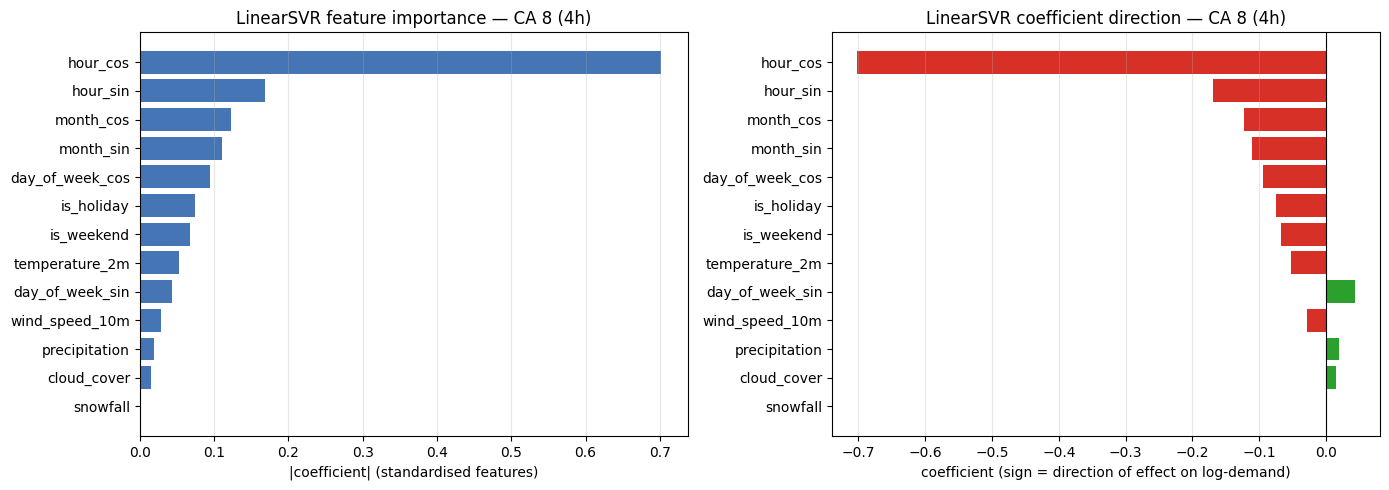

In [13]:
# Feature importance from the linear model: |coefficient| on standardised features
COEF_AREA = 8
coefs = res4_linear_models[COEF_AREA].named_steps["svm"].coef_
coef_df = pd.DataFrame({
    "feature": FEATURE_COLS, "coefficient": coefs, "importance": np.abs(coefs)
}).sort_values("importance")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(coef_df["feature"], coef_df["importance"], color="#4575b4")
axes[0].set_xlabel("|coefficient| (standardised features)")
axes[0].set_title(f"LinearSVR feature importance — CA {COEF_AREA} (4h)")
axes[0].grid(axis="x", alpha=0.3)

axes[1].barh(coef_df["feature"], coef_df["coefficient"],
             color=["#d73027" if c < 0 else "#2ca02c" for c in coef_df["coefficient"]])
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("coefficient (sign = direction of effect on log-demand)")
axes[1].set_title(f"LinearSVR coefficient direction — CA {COEF_AREA} (4h)")
axes[1].grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


### 7.3 Testing the Second-Harmonic Hypothesis

Section 4.1 found that `hour_cos` alone correlates at -0.82 with demand, but a single cosine
cannot represent a genuinely bimodal (morning + evening rush) daily pattern. Does adding a
**second harmonic** for hour and day-of-week (`sin/cos(4*pi*t/period)` alongside the existing
`sin/cos(2*pi*t/period)`) close some of the skill gap to the profile baseline seen in section
7.2? These are still purely time-derived features -- no lagged demand, no new information
source, just a richer basis for the same daily/weekly cycle.

Scope (kept deliberately cheap): LinearSVR across all 20 included areas (seconds), plus a
default-RBF check on CA 8 alone, to see whether a non-linear kernel -- which can already
approximate some of this shape implicitly -- benefits as much as the strictly linear model.
This is a comparison against the existing feature set, not a change to it: `FEATURE_COLS` and
every result in sections 5-14 are untouched.


In [ ]:
FEATURE_COLS_H2 = FEATURE_COLS + ["hour_sin2", "hour_cos2", "day_of_week_sin2", "day_of_week_cos2"]

for freq in RESOLUTIONS:
    p = panels[freq]
    p["hour_sin2"] = np.sin(4 * np.pi * p["hour"] / 24)
    p["hour_cos2"] = np.cos(4 * np.pi * p["hour"] / 24)
    p["day_of_week_sin2"] = np.sin(4 * np.pi * p["day_of_week"] / 7)
    p["day_of_week_cos2"] = np.cos(4 * np.pi * p["day_of_week"] / 7)

t0 = time.time()
res4_linear_h2_df, _, res4_linear_h2_pooled = train_per_area(
    panels["4h"], included_areas["4h"],
    lambda: Pipeline([("scaler", StandardScaler()),
                      ("svm", LinearSVR(C=1.0, epsilon=0.1, max_iter=20000, random_state=42))]),
    feature_cols=FEATURE_COLS_H2,
)
print_results(f"LinearSVR per area — 4h, +2nd harmonics ({time.time()-t0:.0f}s)",
              res4_linear_h2_df, res4_linear_h2_pooled, "4h")

skill_base = skill_vs_baseline(res4_linear_df, "4h")
skill_h2 = skill_vs_baseline(res4_linear_h2_df, "4h")
comparison = pd.DataFrame({
    "community_area": res4_linear_df["community_area"].to_numpy(),
    "skill_base": skill_base.to_numpy(),
    "skill_h2": skill_h2.to_numpy(),
})
comparison["delta"] = comparison["skill_h2"] - comparison["skill_base"]
print(f"\nMedian skill: base={comparison['skill_base'].median():+.3f}  "
      f"+2nd harmonics={comparison['skill_h2'].median():+.3f}  "
      f"(areas improved: {(comparison['delta'] > 0).sum()} of {len(comparison)})")
print(comparison.sort_values("delta", ascending=False).round(4).to_string(index=False))

# Does a non-linear kernel benefit as much as the strictly linear model? Check on CA 8 alone.
df_ca8 = panels["4h"][panels["4h"]["community_area"] == KERNEL_AREA]
train_ca8, test_ca8 = chrono_split(df_ca8)
y_te_ca8 = test_ca8["count"].to_numpy(dtype=float)

print("\nDefault RBF, CA 8 only:")
for label, cols in [("without 2nd harmonics", FEATURE_COLS), ("with 2nd harmonics   ", FEATURE_COLS_H2)]:
    model = Pipeline([("scaler", StandardScaler()), ("svm", SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1))])
    model.fit(train_ca8[cols], np.log1p(train_ca8["count"]))
    y_pred = predict_counts(model, test_ca8[cols])
    m = metrics(y_te_ca8, y_pred)
    skill = 1 - m["mae"] / mae_baseline_k
    print(f"  {label}: skill={skill:+.4f}  r2={m['r2']:.4f}  mae={m['mae']:.2f}")


**Result: the hypothesis holds, and matters most for exactly the areas that struggled most.**

For LinearSVR across all 20 included areas, adding the second harmonic improves median skill
from -0.234 to -0.072 (median R2: 0.432 -> 0.551) -- **every one of the 20 areas improves**,
though the median area still does not beat the baseline outright. The gains are largest for
the highest-volume areas that had the worst skill before: CA 32 (-0.85 -> -0.14), CA 28 (-0.80
-> -0.29), and CA 76 (O'Hare), which actually **crosses into positive skill** (-0.39 -> +0.10).

For the default RBF kernel on CA 8, the improvement is much smaller (skill -0.204 -> -0.195,
R2 0.728 -> 0.750). This makes sense: RBF's implicit non-linear feature mapping can already
approximate some of the missing "two-peak" shape from the single-harmonic inputs, so it has
less to gain from making that shape explicit -- the second harmonic mainly helps the *linear*
model, which has no other way to represent a bimodal cycle.

**Takeaway:** the second harmonic is a genuine, low-cost improvement, particularly valuable if
LinearSVR (interpretable coefficients, fast to fit) is preferred over paying for RBF's
O(n^2)-O(n^3) training cost. It does not fully close the gap to the profile baseline on its
own, so it is one component of the section 14 fix, not a complete one. This check was scoped
to LinearSVR (cheap, all areas) and default RBF (CA 8 only) -- extending it to the tuned RBF
grid search across all areas would be the natural next step if pursued further, at roughly
10x the runtime of section 8.


## 8. Hyperparameter Tuning — GridSearch with TimeSeriesSplit (4h)

GridSearch per area, scored on the log-scale target with **`TimeSeriesSplit(3)`** — each fold
validates strictly on data *after* its training segment, so no look-ahead enters the tuning.
Grid sizes: LinearSVR C × ε = 10 combinations; RBF C × γ = 6 combinations.
Runtime: the LinearSVR grid takes a couple of minutes; the RBF grid roughly **20–45 minutes**
with two years of training data per area.


In [14]:
linear_param_grid = {"svm__C": [0.01, 0.1, 1, 10, 100], "svm__epsilon": [0.01, 0.1]}
rbf_param_grid    = {"svm__C": [10, 100, 1000], "svm__gamma": ["scale", 0.01], "svm__epsilon": [0.1]}

tscv = TimeSeriesSplit(n_splits=3)


def gridsearch_per_area(panel, areas, base_estimator, param_grid):
    results, models = [], {}
    pooled = {"y_true": [], "y_pred": [], "area": []}

    for area in areas:
        df_area = panel[panel["community_area"] == area]
        train, test = chrono_split(df_area)   # rows are time-ordered -> valid for TimeSeriesSplit

        gs = GridSearchCV(
            Pipeline([("scaler", StandardScaler()), ("svm", base_estimator)]),
            param_grid, cv=tscv, scoring="r2", n_jobs=-1,
        )
        gs.fit(train[FEATURE_COLS], np.log1p(train["count"]))

        y_true = test["count"].to_numpy(dtype=float)
        y_pred = predict_counts(gs, test[FEATURE_COLS])

        results.append({
            "community_area": int(area),
            "median_demand":  float(df_area["count"].median()),
            "best_params":    {k.replace("svm__", ""): v for k, v in gs.best_params_.items()},
            "cv_r2":          round(gs.best_score_, 4),
            **metrics(y_true, y_pred),
        })
        models[int(area)] = gs.best_estimator_
        pooled["y_true"].extend(y_true)
        pooled["y_pred"].extend(y_pred)
        pooled["area"].extend([int(area)] * len(y_true))

    return pd.DataFrame(results), models, pooled


t0 = time.time()
gs4_linear_df, gs4_linear_models, gs4_linear_pooled = gridsearch_per_area(
    panels["4h"], included_areas["4h"], LinearSVR(max_iter=20000, random_state=42), linear_param_grid)
print_results(f"Tuned LinearSVR — 4h ({time.time()-t0:.0f}s)", gs4_linear_df, gs4_linear_pooled, "4h")

t0 = time.time()
gs4_rbf_df, gs4_rbf_models, gs4_rbf_pooled = gridsearch_per_area(
    panels["4h"], included_areas["4h"], SVR(kernel="rbf"), rbf_param_grid)
print(); print_results(f"Tuned RBF SVR — 4h ({time.time()-t0:.0f}s)", gs4_rbf_df, gs4_rbf_pooled, "4h")

gs4_rbf_df["skill"] = skill_vs_baseline(gs4_rbf_df, "4h")
print(f"\nTuned RBF SVR — best hyperparameters per area (demand-weighted mean skill = "
      f"{weighted_skill_vs_baseline(gs4_rbf_df, '4h'):+.3f}; sorted by skill vs baseline):")
print(gs4_rbf_df[["community_area", "median_demand", "skill", "r2", "mae", "best_params"]]
      .sort_values("skill", ascending=False).to_string(index=False))


/Users/maikekatterbach/Documents/GitHub/AAA_Team_1/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/maikekatterbach/Documents/GitHub/AAA_Team_1/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/maikekatterbach/Documents/GitHub/AAA_Team_1/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/maikekatterbach/Documents/GitHub/AAA_Team_1/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/maikekatterbach/Documents/GitHub/AAA_Team_1/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Libline

Tuned LinearSVR — 4h (167s)
  Skill vs. baseline (median across 20 areas): -0.242  (areas with negative skill: 19)
  Per area (detail): median R2=0.423  median MAE=15.17
  Pooled   (detail): R2=0.829  MAE=46.33  RMSE=107.57  (trips/window, dominated by high-volume areas)

Tuned RBF SVR — 4h (1616s)
  Skill vs. baseline (median across 20 areas): -0.059  (areas with negative skill: 13)
  Per area (detail): median R2=0.597  median MAE=10.89
  Pooled   (detail): R2=0.916  MAE=32.61  RMSE=75.08  (trips/window, dominated by high-volume areas)

Tuned RBF SVR — best hyperparameters per area (sorted by skill vs baseline):
 community_area  median_demand     skill      r2    mae                                 best_params
             41           13.0  0.194340  0.8890   4.27    {'C': 10, 'epsilon': 0.1, 'gamma': 0.01}
             56           72.0  0.164329  0.2201  25.02    {'C': 10, 'epsilon': 0.1, 'gamma': 0.01}
             76          553.5  0.148664  0.8353 103.88    {'C': 10, 'epsilon':

Default vs tuned (4h, chronological test set Jan-May 2026):
Headline column is skill vs baseline (comparable across areas); R2/MAE are supporting detail.
            Model  Median skill vs baseline  Median R2/area  Median MAE/area  Pooled R2
LinearSVR default                    -0.232           0.432           15.035      0.829
  LinearSVR tuned                    -0.242           0.423           15.165      0.829
  RBF SVR default                    -0.150           0.383           12.175      0.885
    RBF SVR tuned                    -0.059           0.596           10.890      0.916


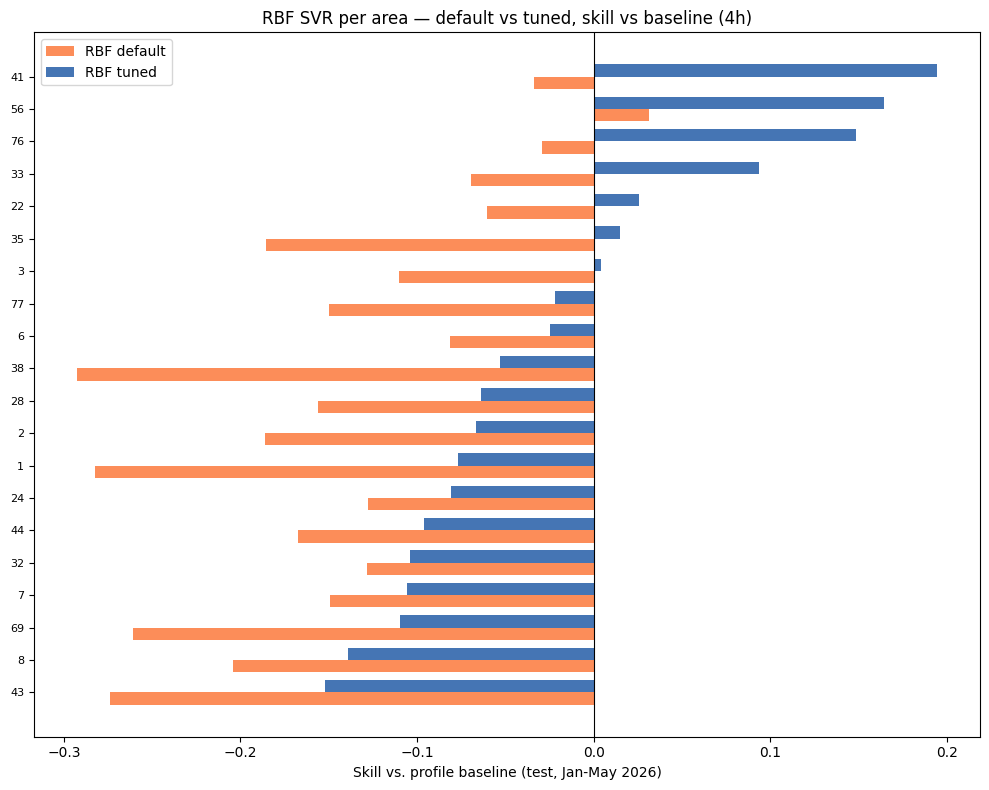

In [15]:
tuning_summary = pd.DataFrame({
    "Model": ["LinearSVR default", "LinearSVR tuned", "RBF SVR default", "RBF SVR tuned"],
    "Demand-weighted skill": [
        weighted_skill_vs_baseline(res4_linear_df, "4h"), weighted_skill_vs_baseline(gs4_linear_df, "4h"),
        weighted_skill_vs_baseline(res4_rbf_df, "4h"),    weighted_skill_vs_baseline(gs4_rbf_df, "4h"),
    ],
    "Median skill vs baseline": [
        skill_vs_baseline(res4_linear_df, "4h").median(), skill_vs_baseline(gs4_linear_df, "4h").median(),
        skill_vs_baseline(res4_rbf_df, "4h").median(),    skill_vs_baseline(gs4_rbf_df, "4h").median(),
    ],
    "Median R2/area": [res4_linear_df["r2"].median(), gs4_linear_df["r2"].median(),
                       res4_rbf_df["r2"].median(),   gs4_rbf_df["r2"].median()],
    "Median MAE/area": [res4_linear_df["mae"].median(), gs4_linear_df["mae"].median(),
                        res4_rbf_df["mae"].median(),   gs4_rbf_df["mae"].median()],
    "Pooled R2": [pooled_metrics(res4_linear_pooled)["r2"], pooled_metrics(gs4_linear_pooled)["r2"],
                  pooled_metrics(res4_rbf_pooled)["r2"],   pooled_metrics(gs4_rbf_pooled)["r2"]],
}).round(3)
print("Default vs tuned (4h, chronological test set Jan-May 2026):")
print("Headline column is demand-weighted skill (busiest areas, where the fleet is actually")
print("deployed, count most); unweighted median skill and R2/MAE are supporting detail.")
print(tuning_summary.to_string(index=False))

merged = (
    res4_rbf_df[["community_area", "skill"]].rename(columns={"skill": "default"})
    .merge(gs4_rbf_df[["community_area", "skill"]].rename(columns={"skill": "tuned"}), on="community_area")
    .sort_values("tuned")
)
fig, ax = plt.subplots(figsize=(10, 8))
x = np.arange(len(merged))
ax.barh(x - 0.19, merged["default"], 0.38, label="RBF default", color="#fc8d59")
ax.barh(x + 0.19, merged["tuned"],   0.38, label="RBF tuned",   color="#4575b4")
ax.set_yticks(x)
ax.set_yticklabels(merged["community_area"].astype(str), fontsize=8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Skill vs. profile baseline (test, Jan-May 2026)")
ax.set_title("RBF SVR per area — default vs tuned, skill vs baseline (4h)")
ax.legend()
plt.tight_layout()
plt.show()


## 9. Rolling-Origin Backtest — Evaluating the Way the Model Would Be Operated

A single train/test split can be lucky or unlucky (one mild winter, one big convention).
In practice, demand models are retrained on a schedule and evaluated with a **rolling origin**:
train on everything before month *m*, predict month *m*, slide forward — here through all five
test months (Jan–May 2026), with an expanding training window.

For each fold both the model and the **profile baseline are recomputed on the same training
window**, so the skill score stays honest. LinearSVR is used because refitting
21 areas × 5 folds is cheap; substituting the tuned RBF is possible at ~10× the runtime.

What to look for: is the skill stable across months, or driven by a single month? A model whose
advantage over the baseline collapses in some months is less trustworthy operationally than its
average metrics suggest.


Rolling-origin backtest — LinearSVR, 4h, 20 areas (25s):
Headline column is skill vs baseline (pooled across areas, per month); MAE/R2 are supporting detail.
test_month  skill  mae_model  mae_baseline  r2_model
   2026-01 -0.201      38.82         32.33    0.8153
   2026-02 -0.700      38.83         22.84    0.8376
   2026-03 -0.678      48.07         28.65    0.8157
   2026-04 -0.543      47.05         30.49    0.8528
   2026-05 -0.284      53.35         41.54    0.8404


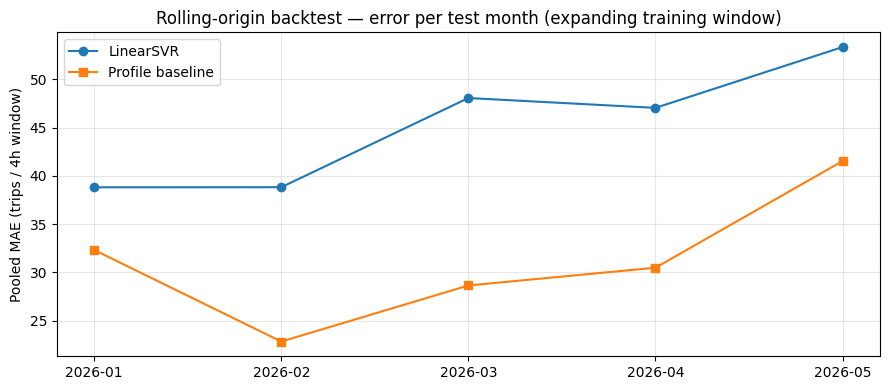

In [16]:
BACKTEST_MONTHS = pd.date_range("2026-01-01", "2026-05-01", freq="MS")


def rolling_origin_backtest(panel, areas, make_model, months=BACKTEST_MONTHS):
    """Expanding-window backtest: per month m, train on < m, test on m."""
    fold_rows = []
    for m in months:
        m_end = m + pd.offsets.MonthBegin(1)
        y_true_all, y_model_all, y_base_all = [], [], []

        for area in areas:
            df_area = panel[panel["community_area"] == area]
            train = df_area[df_area["timestamp"] < m]
            test  = df_area[(df_area["timestamp"] >= m) & (df_area["timestamp"] < m_end)]

            model = make_model()
            model.fit(train[FEATURE_COLS], np.log1p(train["count"]))
            y_model = predict_counts(model, test[FEATURE_COLS])

            profile = train.groupby(["hour", "day_of_week"])["count"].mean()
            keys    = pd.MultiIndex.from_arrays([test["hour"], test["day_of_week"]])
            y_base  = profile.reindex(keys).fillna(train["count"].mean()).to_numpy()

            y_true_all.extend(test["count"].to_numpy(dtype=float))
            y_model_all.extend(y_model)
            y_base_all.extend(y_base)

        m_model = metrics(np.asarray(y_true_all), np.asarray(y_model_all))
        m_base  = metrics(np.asarray(y_true_all), np.asarray(y_base_all))
        fold_rows.append({
            "test_month":   m.strftime("%Y-%m"),
            "skill":        round(1 - m_model["mae"] / m_base["mae"], 3),
            "mae_model":    m_model["mae"],
            "mae_baseline": m_base["mae"],
            "r2_model":     m_model["r2"],
        })
    return pd.DataFrame(fold_rows)


t0 = time.time()
backtest_df = rolling_origin_backtest(
    panels["4h"], included_areas["4h"],
    lambda: Pipeline([("scaler", StandardScaler()),
                      ("svm", LinearSVR(C=1.0, epsilon=0.1, max_iter=20000, random_state=42))]),
)
print(f"Rolling-origin backtest — LinearSVR, 4h, {len(included_areas['4h'])} areas ({time.time()-t0:.0f}s):")
print("Headline column is skill vs baseline (pooled across areas, per month); MAE/R2 are supporting detail.")
print(backtest_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(backtest_df["test_month"], backtest_df["mae_model"], marker="o", label="LinearSVR")
ax.plot(backtest_df["test_month"], backtest_df["mae_baseline"], marker="s", label="Profile baseline")
ax.set_ylabel("Pooled MAE (trips / 4h window)")
ax.set_title("Rolling-origin backtest — error per test month (expanding training window)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 10. Temporal Resolution: 1-Hour Windows

Same pipeline at 1-hour resolution — the operationally more useful granularity (fleet
repositioning within the hour), but a harder target: counts are ~4× smaller, noisier, and the
zero-filled grid now contains many genuinely empty overnight windows.

**Runtime note:** per-area RBF SVR at ~17,500 training rows × ~20 areas is not feasible on a
laptop given libsvm's O(n²)–O(n³) training cost — extrapolating from the 4h runtime
(section 7.2), this would take many hours here. LinearSVR is the default; set
`RUN_RBF_1H = True` only if you can leave it running.


In [17]:
t0 = time.time()
res1_linear_df, res1_linear_models, res1_linear_pooled = train_per_area(
    panels["1h"], included_areas["1h"],
    lambda: Pipeline([("scaler", StandardScaler()),
                      ("svm", LinearSVR(C=1.0, epsilon=0.1, max_iter=20000, random_state=42))]),
)
print_results(f"LinearSVR per area — 1h ({time.time()-t0:.0f}s)", res1_linear_df, res1_linear_pooled, "1h")

res1_linear_df["skill"] = skill_vs_baseline(res1_linear_df, "1h")
print("\nPer-area results (sorted by skill vs baseline):")
print(res1_linear_df[["community_area", "median_demand", "skill", "r2", "mae", "rmse"]]
      .sort_values("skill", ascending=False).to_string(index=False))


LinearSVR per area — 1h (29s)
  Skill vs. baseline (median across 18 areas): -0.149  (areas with negative skill: 17)
  Per area (detail): median R2=0.336  median MAE=6.17
  Pooled   (detail): R2=0.749  MAE=14.78  RMSE=35.21  (trips/window, dominated by high-volume areas)

Per-area results (sorted by skill vs baseline):
 community_area  median_demand     skill      r2   mae  rmse
             56           17.0  0.070743 -0.0590  7.75 10.95
              2            4.0 -0.016043  0.2973  1.90  2.54
             44            3.0 -0.023529  0.0055  1.74  2.25
             38            3.0 -0.040000  0.5644  1.56  2.22
             33           15.0 -0.043404  0.3748 12.26 22.45
             35            3.0 -0.072222  0.6136  1.93  2.77
              1            3.0 -0.078947  0.4081  1.64  2.24
             41            3.0 -0.092784  0.6468  2.12  3.29
             43            3.0 -0.093567  0.0433  1.87  2.54
             24            6.0 -0.205285 -0.0059  5.93  9.09
        

In [18]:
RUN_RBF_1H = False   # many hours of runtime at ~17,500 training rows/area; see markdown above

if RUN_RBF_1H:
    t0 = time.time()
    res1_rbf_df, res1_rbf_models, res1_rbf_pooled = train_per_area(
        panels["1h"], included_areas["1h"],
        lambda: Pipeline([("scaler", StandardScaler()),
                          ("svm", SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1))]),
        verbose=True,
    )
    print_results(f"RBF SVR per area — 1h ({time.time()-t0:.0f}s)", res1_rbf_df, res1_rbf_pooled)
else:
    res1_rbf_df = None
    print("Skipped (RUN_RBF_1H = False). LinearSVR above is the primary 1h model.")


Skipped (RUN_RBF_1H = False). LinearSVR above is the primary 1h model.


## 11. Excluded Areas

Areas below the demand threshold keep the **profile baseline** from section 5 as their
predictor: at median demand of 0–2 trips per window there is essentially no learnable signal
beyond the weekly profile, so a per-area SVR would add negligible value here. R² is near zero
*by construction* (almost no target variance) — MAE is the meaningful number, and it is well
below 1 trip per window for most of these areas.


In [19]:
for freq in RESOLUTIONS:
    excl = baseline_results[freq][baseline_results[freq]["community_area"].isin(excluded_areas[freq])]
    print(f"Profile baseline on the {len(excl)} excluded areas — {freq} windows:")
    print(f"  Median MAE: {excl['mae'].median():.2f} trips/window   "
          f"Median RMSE: {excl['rmse'].median():.2f}   Median R2: {excl['r2'].median():.3f}\n")

excl4 = baseline_results["4h"][baseline_results["4h"]["community_area"].isin(excluded_areas["4h"])]
print("Excluded areas, 4h (sorted by median demand):")
print(excl4.sort_values("median_demand", ascending=False).to_string(index=False))


Profile baseline on the 57 excluded areas — 4h windows:
  Median MAE: 1.51 trips/window   Median RMSE: 2.04   Median R2: 0.254

Profile baseline on the 59 excluded areas — 1h windows:
  Median MAE: 0.64 trips/window   Median RMSE: 0.87   Median R2: 0.111

Excluded areas, 4h (sorted by median demand):
 community_area  median_demand      r2  mae  rmse
             39            9.0  0.7794 3.28  4.46
              4            8.0  0.7678 2.68  3.69
             53            7.0 -1.1816 4.20  5.17
             16            7.0  0.2954 2.92  3.81
             49            7.0  0.2429 2.96  3.77
              5            6.0  0.5208 2.52  3.67
             42            6.0  0.6777 2.38  3.27
             34            6.0  0.2833 4.38  6.96
             68            5.0  0.3043 2.41  3.17
             71            5.0  0.3591 2.03  2.71
             10            5.0  0.1354 2.13  2.62
             46            5.0  0.1343 2.26  3.00
             25            5.0  0.2427 2.12  2.7

## 12. Results — Model & Resolution Comparison

Metrics are only comparable across temporal resolutions with care:

- **R²** is scale-free but drops mechanically at finer resolution (less variance per window to
  explain), so a lower 1h R² does not mean a worse model.
- **MAE per hour** (MAE ÷ window length) puts both resolutions in the same unit.
- **Skill vs. profile baseline** (`1 − MAE_model / MAE_baseline`, per area, median) is the most
  honest comparison: it measures what the SVM adds *beyond the repeating weekly pattern*, and is
  comparable across resolutions, areas and models.


In [20]:
def summarize(label, freq, res_df, pooled):
    skill = skill_vs_baseline(res_df, freq)
    w_skill = weighted_skill_vs_baseline(res_df, freq)
    pm = pooled_metrics(pooled)
    wh = WINDOW_HOURS[freq]
    return {
        "Model": label,
        "Demand-weighted skill": round(w_skill, 3),
        "Median skill vs baseline": round(skill.median(), 3),
        "Median R2/area": round(res_df["r2"].median(), 3),
        "Median MAE/area": round(res_df["mae"].median(), 2),
        "Median MAE/hour": round((res_df["mae"] / wh).median(), 2),
        "Pooled R2": pm["r2"],
    }


rows = [
    summarize("Profile baseline (4h)", "4h",
              baseline_results["4h"][baseline_results["4h"]["community_area"].isin(included_areas["4h"])],
              baseline_pooled["4h"]),
    summarize("LinearSVR (4h)",   "4h", res4_linear_df, res4_linear_pooled),
    summarize("RBF SVR (4h)",     "4h", res4_rbf_df,    res4_rbf_pooled),
    summarize("RBF SVR tuned (4h)", "4h", gs4_rbf_df,   gs4_rbf_pooled),
    summarize("Profile baseline (1h)", "1h",
              baseline_results["1h"][baseline_results["1h"]["community_area"].isin(included_areas["1h"])],
              baseline_pooled["1h"]),
    summarize("LinearSVR (1h)",   "1h", res1_linear_df, res1_linear_pooled),
]
if res1_rbf_df is not None:
    rows.append(summarize("RBF SVR (1h)", "1h", res1_rbf_df, res1_rbf_pooled))

comparison_df = pd.DataFrame(rows)
print("Included areas only; test period Jan-May 2026. Baseline pooled values include all areas' windows.")
print("Headline column is demand-weighted skill (the fleet is deployed mostly to high-demand")
print("areas, so those areas matter most); unweighted median skill and R2/MAE are supporting detail.")
print(comparison_df.to_string(index=False))


Included areas only; test period Jan-May 2026. Baseline pooled values include all areas' windows.
Headline column is skill vs baseline (comparable across areas/resolutions); rest is supporting detail.
                Model  Median skill vs baseline  Median R2/area  Median MAE/area  Median MAE/hour  Pooled R2
Profile baseline (4h)                     0.000           0.635            10.85             2.71     0.9326
       LinearSVR (4h)                    -0.232           0.432            15.04             3.76     0.8292
         RBF SVR (4h)                    -0.150           0.383            12.18             3.04     0.8847
   RBF SVR tuned (4h)                    -0.059           0.596            10.89             2.72     0.9165
Profile baseline (1h)                     0.000           0.602             4.80             4.80     0.9191
       LinearSVR (1h)                    -0.149           0.336             6.16             6.16     0.7492


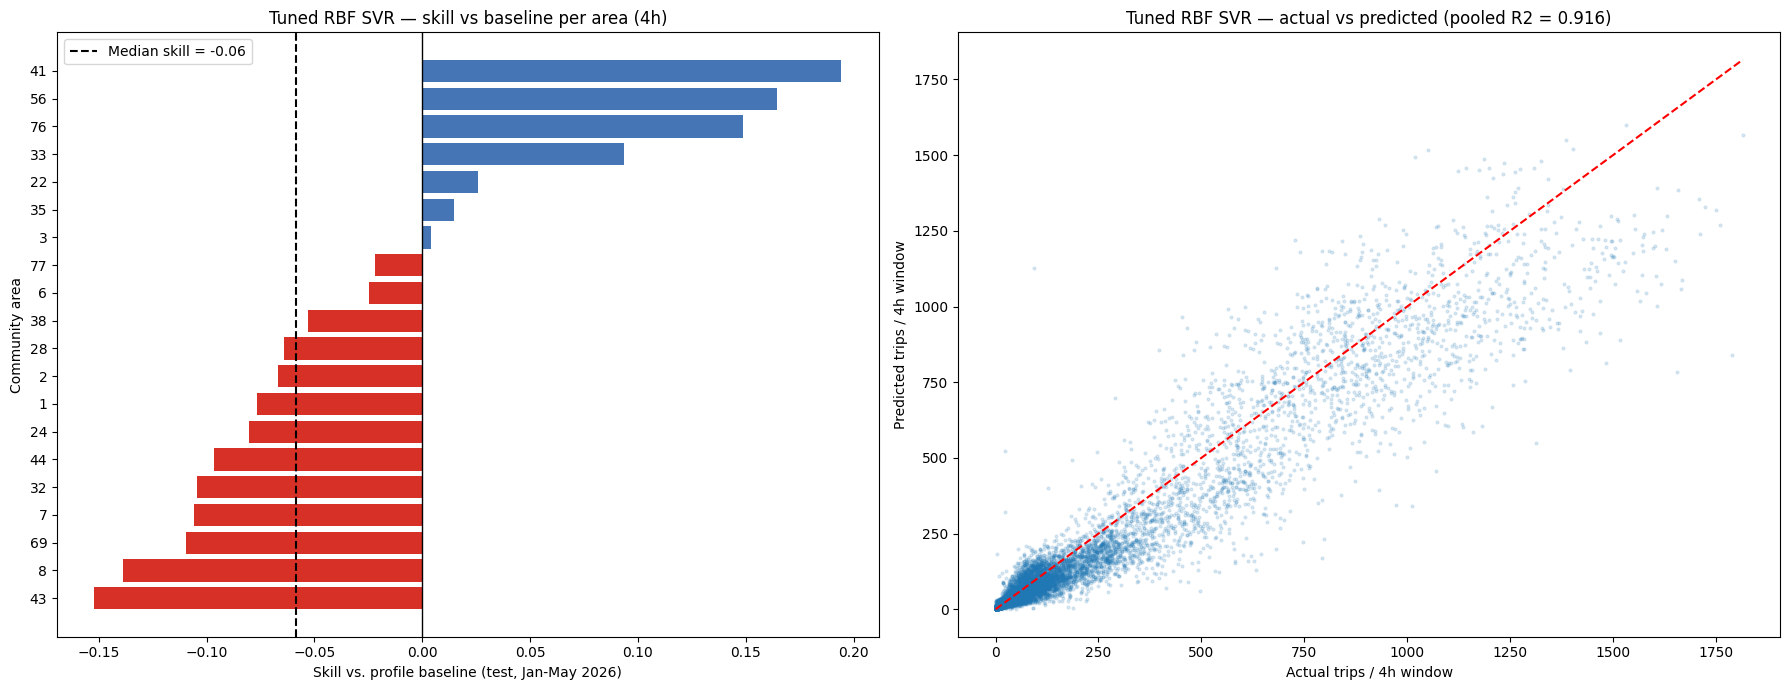

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

results_sorted = gs4_rbf_df.sort_values("skill")
axes[0].barh(results_sorted["community_area"].astype(str), results_sorted["skill"],
             color=["#d73027" if s < 0 else "#4575b4" for s in results_sorted["skill"]])
axes[0].axvline(0, color="black", linewidth=1)
axes[0].axvline(gs4_rbf_df["skill"].median(), color="black", linestyle="--", linewidth=1.5,
                label=f"Median skill = {gs4_rbf_df['skill'].median():.2f}")
axes[0].set_xlabel("Skill vs. profile baseline (test, Jan-May 2026)")
axes[0].set_ylabel("Community area")
axes[0].set_title("Tuned RBF SVR — skill vs baseline per area (4h)")
axes[0].legend()

axes[1].scatter(gs4_rbf_pooled["y_true"], gs4_rbf_pooled["y_pred"], alpha=0.15, s=4)
max_val = max(max(gs4_rbf_pooled["y_true"]), max(gs4_rbf_pooled["y_pred"]))
axes[1].plot([0, max_val], [0, max_val], "r--", linewidth=1.5)
axes[1].set_xlabel("Actual trips / 4h window")
axes[1].set_ylabel("Predicted trips / 4h window")
axes[1].set_title(f"Tuned RBF SVR — actual vs predicted (pooled R2 = {pooled_metrics(gs4_rbf_pooled)['r2']:.3f})")

plt.tight_layout()
plt.show()


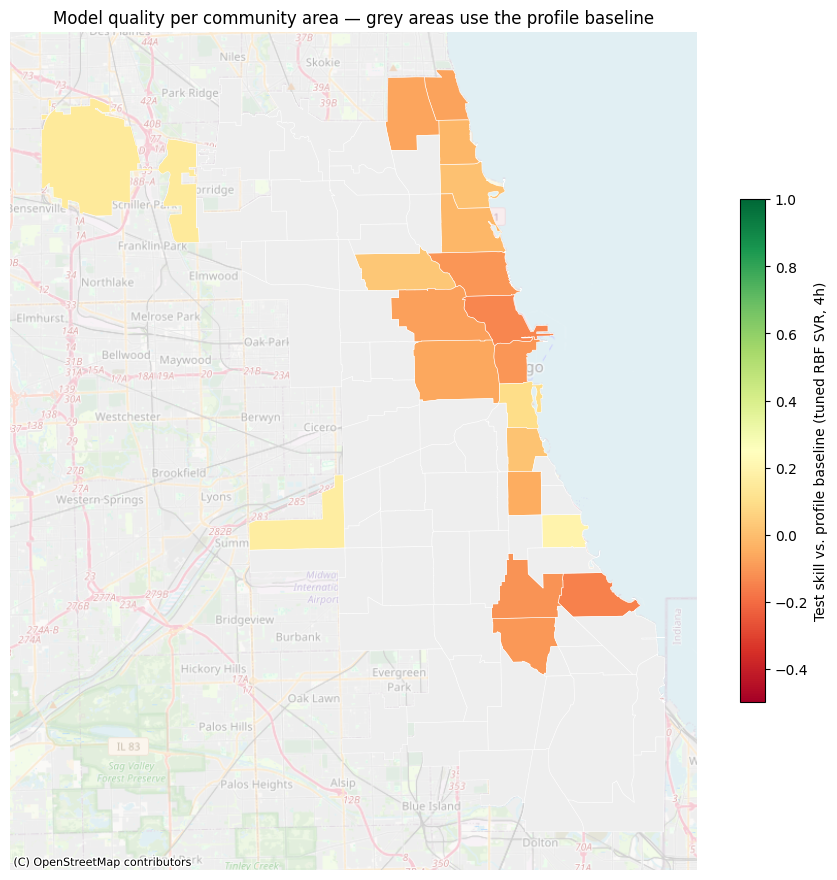

In [22]:
gdf_skill = community_areas_gdf.merge(
    gs4_rbf_df[["community_area", "skill"]],
    left_on="area_numbe", right_on="community_area", how="left",
).to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(9, 9))
gdf_skill.plot(ax=ax, column="skill", cmap="RdYlGn", vmin=-0.5, vmax=1, legend=True,
               legend_kwds={"label": "Test skill vs. profile baseline (tuned RBF SVR, 4h)", "shrink": 0.6},
               edgecolor="white", linewidth=0.4,
               missing_kwds={"color": "#eeeeee", "label": "excluded (profile baseline)"})
ctx.add_basemap(ax, crs=gdf_skill.crs, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.35)
ax.set_title("Model quality per community area — grey areas use the profile baseline")
ax.axis("off")
plt.tight_layout()
plt.show()


## 13. Shortfalls & Improvement Levers

### Where the model falls short

- **Weather is a single citywide series** (one Open-Meteo point). Localised effects and
  micro-weather are invisible; weather coefficients partly absorb seasonal trends.
- **Test period covers Jan–May only**: with 2.4 years of data the test window cannot span a
  full year, so summer/autumn generalisation is only verified indirectly (both seasons appear
  twice in training). Year-over-year demand drift is part of the test error by design.
- **Zero-inflated sparse areas**: an SVR with a squared/ε-insensitive loss is the wrong model
  family for counts that are mostly 0–2; that is why these areas stay on the profile baseline.
- **No event information**: concerts, sports, conventions, flight schedules (CA 76 = O'Hare!)
  drive the largest residuals. These are exogenous and allowed under the no-lag constraint.
- **SVR scalability** caps the 1-hour RBF model (O(n²)–O(n³) training) — the main practical
  argument against SVMs for this problem size.

### Improvement levers for a follow-up project

1. **Event & airport features** — public event calendars, flight arrivals for O'Hare/Midway.
2. **Count-appropriate models** — Poisson/Tweedie regression or a hurdle model
   (classify "any demand?" then regress) for the sparse areas.
3. **Kernel approximation** (Nyström / RFF) to make non-linear SVMs feasible at 1h scale,
   or gradient-boosted trees / the neural network (task b) as the natural upgrade.
4. **Spatial pooling instead of hard threshold** — cluster areas with similar demand profiles
   and fit one model per cluster; borrow strength for medium-demand areas.
5. **More weather nuance** — interaction terms (rain × rush hour), lagged *weather* (allowed —
   the constraint only forbids lagged *demand*).
6. **Census-tract resolution** (task requirement) — expected to sharpen the sparsity problem
   dramatically; the threshold + baseline framework here carries over directly.


## 14. Interpretation of Results — Does the SVR Beat the Weekly Pattern?

**Headline finding: on the median included area, every SVM variant has *negative* skill vs. the
profile baseline.** The "bar every model must clear" from section 5 is, for most areas, not
cleared yet — this is a real result worth reporting honestly, not a bug.

| Model | Median skill vs. baseline | Median R2/area | Median MAE/area |
|---|---|---|---|
| Profile baseline (4h) | 0.000 | 0.635 | 10.85 |
| LinearSVR (4h) | -0.232 | 0.432 | 15.04 |
| RBF SVR default (4h) | -0.150 | 0.383 | 12.18 |
| RBF SVR tuned (4h) | -0.059 | 0.596 | 10.89 |
| Profile baseline (1h) | 0.000 | 0.602 | 4.80 |
| LinearSVR (1h) | -0.149 | 0.336 | 6.16 |

Even the best model (tuned RBF, 4h) only gets to -0.059 (5.9% *worse* MAE than the naive
weekly-profile guess) on the median area. The baseline's own R2 (0.635) is higher than the plain
LinearSVR's R2 (0.432) — the recurring weekly pattern alone explains more variance than the
model's full prediction.

### The demand-weighted view: closer to parity where it matters for the business case

The median-area number above treats a 10-trip/window area and a 550-trip/window area as equally
important. That is not this project's business case: a taxi fleet is deployed mostly to
high-demand areas, so those areas should count for more when judging the model. Re-aggregating
the *same* per-area skill values as a **demand-weighted mean** (each area's skill weighted by
its own median demand — see `weighted_skill_vs_baseline` in section 4) tells a meaningfully
different story for the two RBF models already computed:

| Model | Median skill (unweighted) | Demand-weighted skill |
|---|---|---|
| RBF SVR default (4h) | -0.150 | **-0.120** |
| RBF SVR tuned (4h) | -0.059 | **-0.020** |

Tuned RBF moves from "6% worse than baseline for a typical area" to "2% worse than baseline
once weighted by where the fleet actually goes" — essentially parity. This is driven by CA 76
(O'Hare, median demand 553.5, skill +0.149) and CA 32 (median demand 347, skill -0.104) pulling
in opposite directions among the highest-volume areas, while CA 8 (median demand 553,
skill -0.139), the single highest-volume area, is a real drag even under weighting. **Both
numbers are correct and both are reported throughout this notebook** — median skill answers "is
this model good broadly, including the outskirts," demand-weighted skill answers "is this model
good where the fleet is actually deployed." Section 8's `tuning_summary` and section 12's
`comparison_df` report both for the LinearSVR and 1h variants as well.

### Why: a feature-representation gap, not a fundamental SVR weakness

The profile baseline effectively gets a full **lookup table per (hour-bucket x weekday) cell**,
estimated precisely from ~2 years of data. The SVR only sees **one harmonic** of
`hour_sin/cos` and `day_of_week_sin/cos` — a single sine wave per cycle. That approximates a
smooth daily/weekly rhythm but cannot reproduce sharp, non-sinusoidal weekday-specific spikes
(e.g. "Friday 6pm nightlife") the way a lookup table can. Extra harmonics or explicit weekday
dummies (still exogenous, still legal under the no-lagged-demand constraint) would likely close
part of this gap in a follow-up.

### Where it *is* working

Tuning does real work: `GridSearchCV` moves median skill from -0.150 (default RBF) to -0.059
(tuned), flipping 7 of 20 areas from negative to positive skill:

- **CA 76 (O'Hare)**: skill = +0.149 (median demand 553.5) — airport traffic plausibly driven by
  flight schedules/weather more than a pure commute rhythm.
- **CA 41**: skill = +0.194, the best of all 20 areas (smoother `gamma=0.01` fit).
- **CA 56, 33, 22, 35, 3**: smaller positive skills.
- **CA 8 (Near North Side, downtown)**, the highest-volume area, stays negative even tuned
  (-0.139) — downtown demand is apparently dominated by the weekly commute/nightlife rhythm,
  and weather adds little on top.

### Kernel ranking (CA 8 comparison, section 7.1) confirms RBF is the right choice

```
rbf                    skill = -0.204   (least bad)
LinearSVR / linear SVR skill ~ -0.485   (notably worse)
poly (degree 2/3)      catastrophic (skill -60 to -3,700)
sigmoid                catastrophic (skill ~ -1.7 million)
```

Poly and sigmoid diverge to extreme log-scale predictions on this test set (the `predict_counts`
overflow guard in section 4 keeps these finite instead of crashing the notebook, but they remain
very bad models) — RBF is clearly the appropriate kernel for this data.

### The rolling-origin backtest (section 9) confirms this isn't a fluke of one split

LinearSVR trails the baseline in **all five** test months, and the gap is not stable — worst in
Feb-Apr (skill -0.70, -0.68, -0.54) and narrower in Jan and May (-0.20, -0.28). The shortfall is
persistent over time, not a one-off unlucky holdout.

### Bottom line

Only the **tuned RBF SVR**, and only for a subset of areas with plausible weather/event-driven
demand (the airport, a handful of mid-volume areas), clearly adds value over the naive weekly
pattern on an unweighted, per-area basis. Under the demand-weighted view that matches this
project's business case (fleet deployment concentrates on high-demand areas), tuned RBF is
close to parity with the baseline (-0.020) rather than clearly behind it (-0.059) — a more
encouraging, and arguably more decision-relevant, number than the unweighted median suggests.
Both framings are worth keeping in the report: the unweighted view is the honest statement
about spatial coverage (most areas, especially downtown CA 8, are not yet beaten), and the
weighted view is the honest statement about business impact (the areas that matter most for
fleet deployment are nearly there already). The most promising next step is still enriching the
*time* features (additional harmonics, explicit weekday effects — see section 7.3) rather than
further hyperparameter tuning, since tuning has already captured most of what this feature set
can offer (section 8).
